# Detectors and Results

The NSQ engine provides four detector types, each capturing a different aspect
of the radiation reaching a surface:

| Detector | Result class | Records |
|---|---|---|
| `IrradianceDetector` | `IrradianceMap` | 2D spatial flux map |
| `FarFieldDetector` | `FarFieldPattern` | Angular (θ, φ) intensity distribution |
| `SpectralDetector` | `SpectralResult` | Per-wavelength irradiance map |
| `RayDatabaseDetector` | `RayDatabase` | Full phase-space record (x, y, z, L, M, N, flux, λ) |

Multiple detectors can be active simultaneously in the same scene. Each is
accumulated independently during the trace.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene, Spectrum,
    PointSourceConfig, CollimatedSourceConfig,
    IrradianceDetectorConfig, FarFieldDetectorConfig,
    SpectralDetectorConfig, RayDatabaseConfig,
    LensConfig,
)

spec_green  = Spectrum.monochromatic(0.55)
spec_rgb    = Spectrum(
    wavelengths=np.array([0.45, 0.55, 0.65]),
    weights=np.array([1.0, 1.5, 1.0]),
)

# The demo singlet used throughout this notebook: biconvex N-BK7, f = 49.1 mm.
# Its back focal distance from the rear vertex is 47.4 mm, so with the front
# vertex at z = 0 and 5 mm of centre thickness the paraxial focus sits at
# z = 52.4 mm. Every detector below goes there unless a cell is deliberately
# showing the beam away from focus.
DEMO_LENS = LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7',
                       front_aperture_radius=12.5)
FOCUS_Z = 52.4


## 1. IrradianceDetector

The most common detector. Records total flux deposited in each pixel of a
rectangular grid. The result `IrradianceMap.irradiance` is in **W/mm²**.

Use `IrradianceDetectorConfig(width, height, num_pixels_x, num_pixels_y)` to
configure it.

IrradianceMap shape: (128, 128)
Peak irradiance    : 31.167 W/mm²
Total detected flux: 0.9164 W of 1.0 W launched
Rays on detector   : 183,404


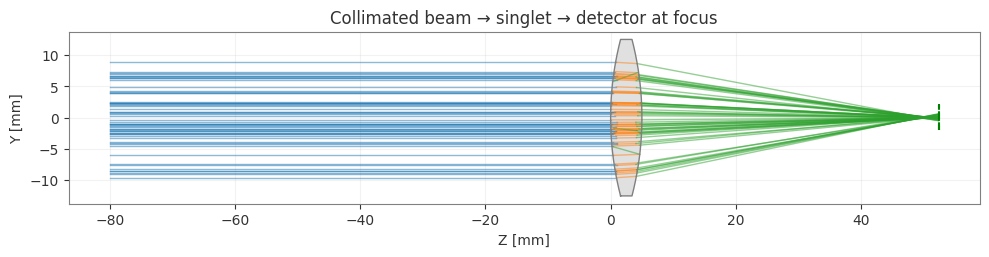

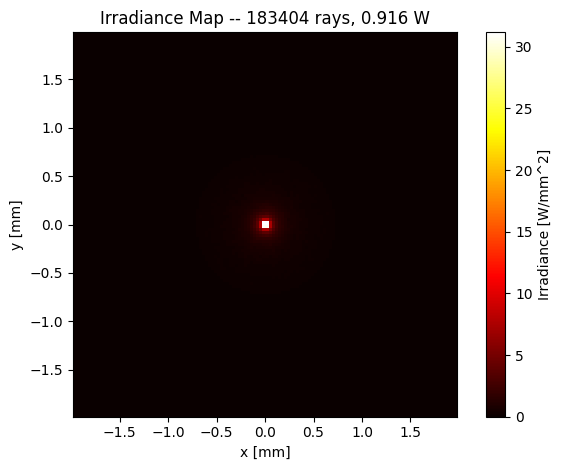

In [2]:
scene = NSQScene()
scene.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec_green, total_flux=1.0, aperture_radius=10.0),
)
scene.add_lens('L', CoordinateSystem(z=0), DEMO_LENS)
scene.add_detector(
    'D_irr', CoordinateSystem(z=FOCUS_Z),
    IrradianceDetectorConfig(width=4, height=4, num_pixels_x=128, num_pixels_y=128),
)

result = scene.trace(num_rays=200_000, seed=42)
irr_map = result.detectors['D_irr']

print(f"IrradianceMap shape: {irr_map.irradiance.shape}")
print(f"Peak irradiance    : {irr_map.irradiance.max():.3f} W/mm\u00b2")
print(f"Total detected flux: {irr_map.total_flux:.4f} W of {result.total_flux_in:.1f} W launched")
print(f"Rays on detector   : {irr_map.num_rays_hit:,}")

# The scene that produced it. Rays are coloured by how many surfaces they have
# already crossed, so the incoming beam, the two glass legs and the converging
# cone are each a different colour.
scene.view(num_rays=60, color_by='bounce',
           title='Collimated beam \u2192 singlet \u2192 detector at focus')
plt.show()

fig = irr_map.plot(cmap='hot')
plt.tight_layout()
plt.show()
plt.close(fig)


### Splatting modes

A ray rarely lands exactly on a pixel centre, so the detector has to decide
how to distribute its flux among neighbouring pixels -- that choice is the
`splat` field of `IrradianceDetectorConfig` (and `SpectralDetectorConfig`):

- `splat="bilinear"` (default) -- spreads flux across the four nearest pixels,
  weighted by distance. Differentiable with respect to both landing position
  and flux.
- `splat="hard"` -- nearest-pixel binning, no spreading. Not differentiable in
  landing position; this is what the fast NumPy forward path uses internally.
- `splat="gaussian"` -- a true Gaussian kernel of width `splat_sigma` pixels,
  truncated and renormalised so no energy is lost. Differentiable, and gives
  the smoothest map of the three at a given ray count, at the cost of
  blurring fine structure below `splat_sigma` pixels.

The difference matters most when rays are scarce: at high ray count all three
converge to the same map, but at low count `hard` binning is visibly grainy
where `bilinear`/`gaussian` are not.

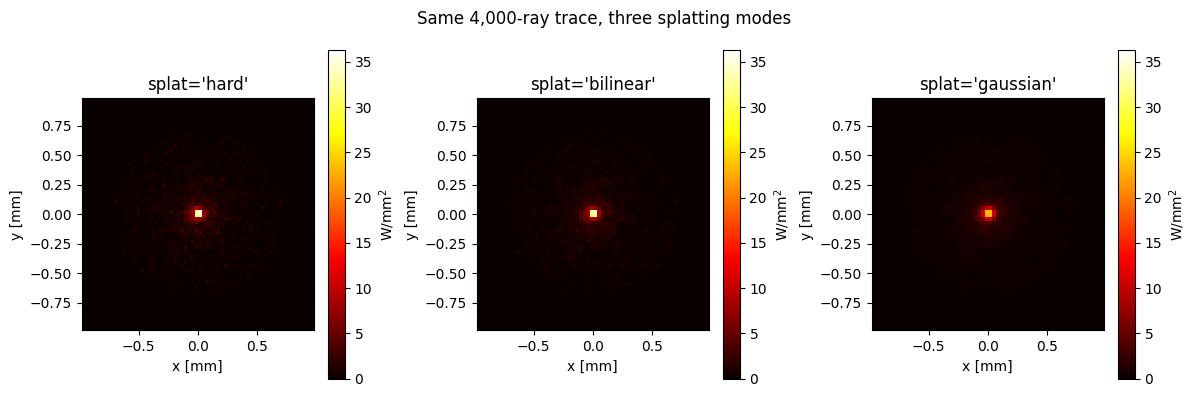

In [3]:
def spot_with_splat(splat, splat_sigma=0.8, n_rays=4_000):
    """Trace a small, ray-starved spot with a given splatting mode."""
    s = NSQScene()
    s.add_source(
        'S', CoordinateSystem(z=-80),
        CollimatedSourceConfig(spectrum=spec_green, total_flux=1.0, aperture_radius=10.0),
    )
    s.add_lens('L', CoordinateSystem(z=0), DEMO_LENS)
    s.add_detector(
        'D', CoordinateSystem(z=FOCUS_Z),
        IrradianceDetectorConfig(width=2, height=2, num_pixels_x=64, num_pixels_y=64,
                                 splat=splat, splat_sigma=splat_sigma),
    )
    return s.trace(num_rays=n_rays, seed=42).detectors['D']


# Deliberately few rays (4,000, not the 200,000 used above) so the binning
# choice is visible: with plenty of rays all three modes converge.
modes = ['hard', 'bilinear', 'gaussian']
maps_splat = [spot_with_splat(m) for m in modes]
vmax_splat = max(m.irradiance.max() for m in maps_splat)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, mode, irr in zip(axes, modes, maps_splat):
    im = ax.imshow(irr.irradiance, origin='lower', cmap='hot', aspect='equal',
                   extent=[irr.x_coords[0], irr.x_coords[-1],
                           irr.y_coords[0], irr.y_coords[-1]],
                   vmin=0, vmax=vmax_splat)
    plt.colorbar(im, ax=ax, label='W/mm$^2$')
    ax.set_title(f"splat='{mode}'")
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.suptitle('Same 4,000-ray trace, three splatting modes', fontsize=12)
plt.tight_layout()
plt.show()

## 2. FarFieldDetector

Records the **angular distribution** of radiation. Instead of spatial position,
it bins each ray by its direction (θ, φ) at the detector surface.

The result `FarFieldPattern.intensity` is in **W/sr** and has shape
`(num_bins_theta, num_bins_phi)`. Note that `intensity` is per unit solid
angle, so summing it does *not* give a flux; use `FarFieldPattern.total_flux`
(in W) for the radiometric total.

The detector is placed at a finite location but uses a very large aperture
(1 km radius by default) so it captures essentially all forward-going rays.

FarFieldPattern shape: (45, 180)  (theta x phi)
Total flux recorded  : 0.9999 W
Peak intensity       : 2.82 W/sr


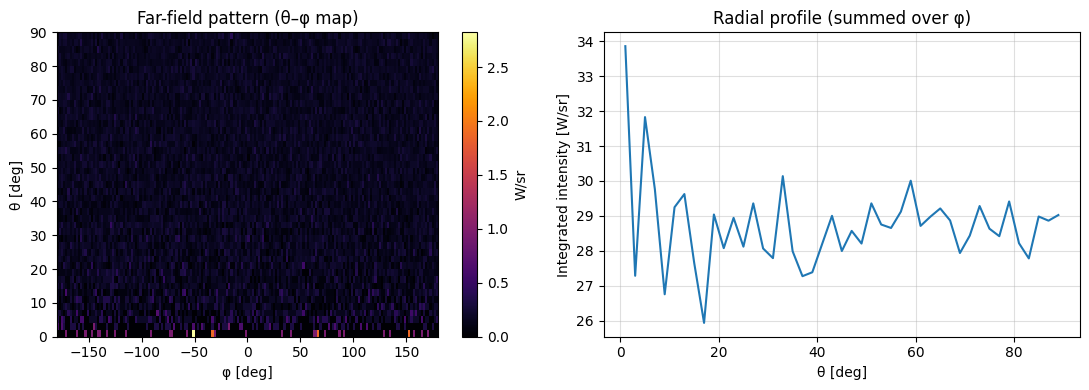

In [4]:
scene_ff = NSQScene()
# Isotropic hemisphere point source
scene_ff.add_source(
    'S', CoordinateSystem(z=0),
    PointSourceConfig(spectrum=spec_green, total_flux=1.0, half_angle_deg=90),
)
# FarFieldDetector captures the hemisphere at z > 0
scene_ff.add_detector(
    'FF', CoordinateSystem(z=100),
    FarFieldDetectorConfig(num_theta=45, num_phi=180),
)

result_ff = scene_ff.trace(num_rays=50_000, seed=42)
ff = result_ff.detectors['FF']

print(f"FarFieldPattern shape: {ff.intensity.shape}  (theta x phi)")
print(f"Total flux recorded  : {ff.total_flux:.4f} W")
print(f"Peak intensity       : {ff.intensity.max():.2f} W/sr")

# Sum over phi to get radial profile
intensity_radial = ff.intensity.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].pcolormesh(ff.phi, ff.theta, ff.intensity, cmap='inferno', shading='auto')
plt.colorbar(im, ax=axes[0], label='W/sr')
axes[0].set_xlabel('φ [deg]'); axes[0].set_ylabel('θ [deg]')
axes[0].set_title('Far-field pattern (θ–φ map)')

axes[1].plot(ff.theta, intensity_radial)
axes[1].set_xlabel('θ [deg]'); axes[1].set_ylabel('Integrated intensity [W/sr]')
axes[1].set_title('Radial profile (summed over φ)')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
plt.close(fig)

## 3. SpectralDetector

Extends the irradiance detector with a third wavelength dimension. The result
`SpectralResult.irradiance` has shape `(ny, nx, n_lambda)` in W/mm², holding the
flux that landed in each wavelength bin (it is binned, not divided by bin width,
so summing over the last axis recovers the broadband irradiance).

Add a `SpectralDetector` via `SpectralDetectorConfig`. Its binning range
(`wl_min`, `wl_max`) is given in **micrometres**, the same unit `Spectrum` uses
and the same unit as every other wavelength in Optiland — the visible band is
`wl_min=0.4, wl_max=0.7`.

This is where a spectral detector earns its keep: N-BK7 is dispersive, so the
three source lines do not share a focus. A higher index means a shorter focal
length, so blue focuses nearest the lens and red furthest from it; over
0.45–0.65 µm the index falls by about 0.011, spreading the focus over roughly
1 mm.

The detector sits at z = 52.4, the *paraxial* 0.55 µm focus. Spherical
aberration in this f/2.45 singlet pulls the real green focus in to about
z = 50, so at this plane it is red that happens to be nearest its own focus and
blue that is furthest past it. That ordering is not obvious from the maps, which
is the point of measuring rather than eyeballing — the per-bin peak irradiance
printed below says it outright.


SpectralResult irradiance shape: (64, 64, 30)  (ny, nx, nlambda)
Occupied bins: [5, 15, 25]
  bin  5  centre 0.455 µm  0.2609 W
  bin 15  centre 0.555 µm  0.3952 W
  bin 25  centre 0.655 µm  0.2599 W
Sum over bins: 0.9160 W  (= total_flux 0.9160 W)

Peak irradiance per bin. Normalising by the flux in each bin removes
the 1 : 1.5 : 1 source weighting, leaving only how tightly each line
is focused at this one plane:
  0.455 µm:     1.90 W/mm² (7.3 per watt in the bin)
  0.555 µm:     5.61 W/mm² (14.2 per watt in the bin)
  0.655 µm:     5.09 W/mm² (19.6 per watt in the bin)


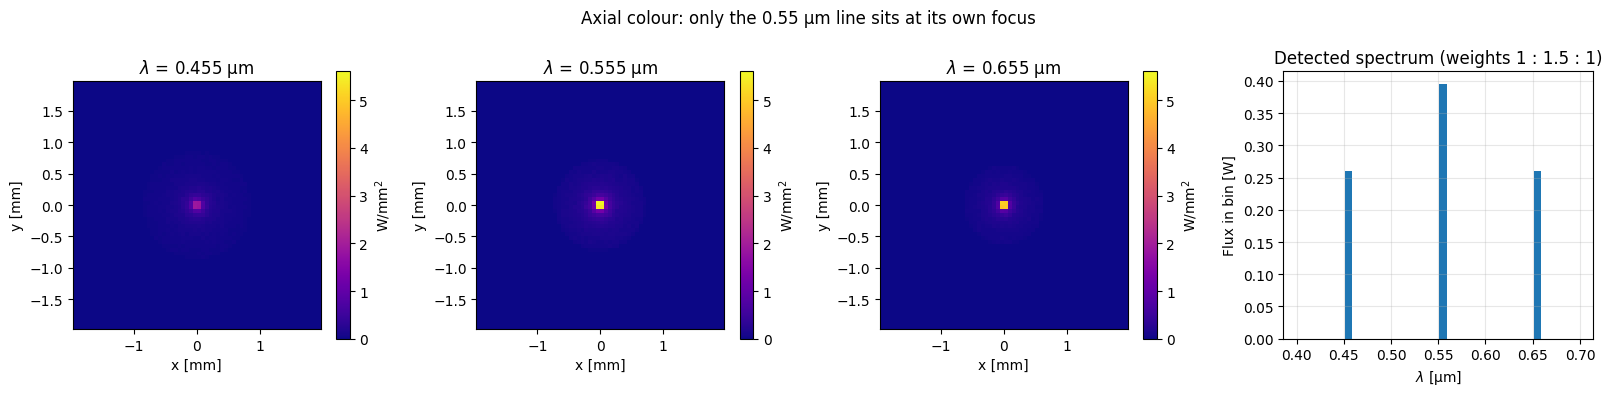

In [5]:
scene_sp = NSQScene()
scene_sp.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec_rgb, total_flux=1.0, aperture_radius=10.0),
)
scene_sp.add_lens('L', CoordinateSystem(z=0), DEMO_LENS)
scene_sp.add_detector(
    'SD', CoordinateSystem(z=FOCUS_Z),
    SpectralDetectorConfig(width=4, height=4, num_pixels_x=64, num_pixels_y=64,
                           wl_min=0.4, wl_max=0.7, num_bins=30),
)

result_sp = scene_sp.trace(num_rays=200_000, seed=42)
sp_result = result_sp.detectors['SD']

pixel_area = (4 / 64) ** 2
flux_per_bin = sp_result.irradiance.sum(axis=(0, 1)) * pixel_area
occupied = np.flatnonzero(flux_per_bin)

print(f"SpectralResult irradiance shape: {sp_result.irradiance.shape}  (ny, nx, nlambda)")
print(f"Occupied bins: {occupied.tolist()}")
for i in occupied:
    print(f"  bin {i:2d}  centre {sp_result.wavelengths[i]:.3f} \u00b5m  "
          f"{flux_per_bin[i]:.4f} W")
print(f"Sum over bins: {flux_per_bin.sum():.4f} W  "
      f"(= total_flux {sp_result.total_flux:.4f} W)")
print("\nPeak irradiance per bin. Normalising by the flux in each bin removes"
      "\nthe 1 : 1.5 : 1 source weighting, leaving only how tightly each line"
      "\nis focused at this one plane:")
for i in occupied:
    peak = sp_result.irradiance[:, :, i].max()
    print(f"  {sp_result.wavelengths[i]:.3f} \u00b5m: {peak:8.2f} W/mm\u00b2 "
          f"({peak / flux_per_bin[i]:.1f} per watt in the bin)")

# Irradiance map in each occupied bin, on a shared colour scale so the
# wavelengths are directly comparable.
maps = [sp_result.irradiance[:, :, i] for i in occupied]
vmax = max(m.max() for m in maps)
extent = [sp_result.x_coords[0], sp_result.x_coords[-1],
          sp_result.y_coords[0], sp_result.y_coords[-1]]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i, E_wl in zip(axes, occupied, maps):
    im = ax.imshow(E_wl, origin='lower', cmap='plasma', aspect='equal',
                   extent=extent, vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax, label='W/mm$^2$')
    ax.set_title(f'$\\lambda$ = {sp_result.wavelengths[i]:.3f} \u00b5m')
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')

axes[3].bar(sp_result.wavelengths, flux_per_bin, width=0.008)
axes[3].set_xlabel('$\\lambda$ [\u00b5m]'); axes[3].set_ylabel('Flux in bin [W]')
axes[3].set_title('Detected spectrum (weights 1 : 1.5 : 1)')
axes[3].grid(True, alpha=0.3)

plt.suptitle('Axial colour: only the 0.55 \u00b5m line sits at its own focus',
             fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig)


## 4. RayDatabaseDetector

Stores complete phase-space information for every ray that hits the detector:
position (x, y, z), direction cosines (L, M, N), flux, and wavelength. This
enables post-trace analysis beyond what the other detectors support.

The `RayDatabase.to_dataframe()` method converts the data to a pandas DataFrame
for convenient analysis.

Rays stored: 45,854
Total flux : 0.9165 W


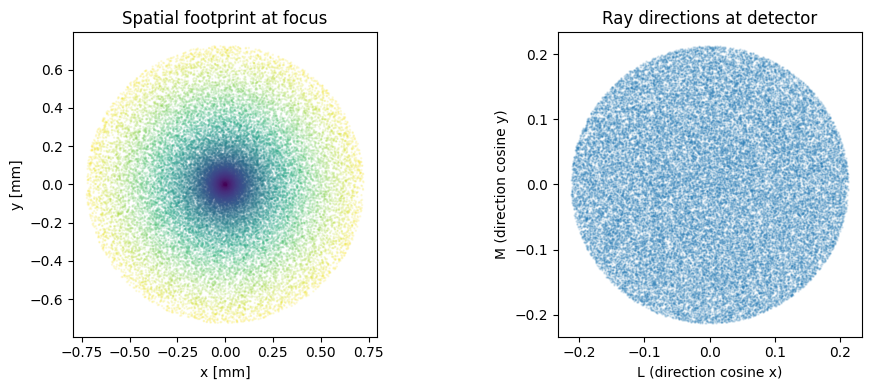

In [6]:
scene_rdb = NSQScene()
scene_rdb.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec_green, total_flux=1.0, aperture_radius=10.0),
)
scene_rdb.add_lens('L', CoordinateSystem(z=0), DEMO_LENS)
scene_rdb.add_detector(
    'RDB', CoordinateSystem(z=FOCUS_Z),
    RayDatabaseConfig(width=4, height=4),
)

result_rdb = scene_rdb.trace(num_rays=50_000, seed=42)
db = result_rdb.detectors['RDB']

print(f"Rays stored: {db.num_rays:,}")
print(f"Total flux : {db.flux.sum():.4f} W")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(db.x, db.y, s=0.5, alpha=0.15, c=db.flux, cmap='viridis')
axes[0].set_xlabel('x [mm]'); axes[0].set_ylabel('y [mm]')
axes[0].set_title('Spatial footprint at focus')
axes[0].set_aspect('equal')

# Direction cosines: the converging cone maps to a filled disk whose radius is
# set by the marginal ray angle, i.e. by the f-number.
axes[1].scatter(db.L, db.M, s=0.5, alpha=0.15)
axes[1].set_xlabel('L (direction cosine x)'); axes[1].set_ylabel('M (direction cosine y)')
axes[1].set_title('Ray directions at detector')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()
plt.close(fig)


## 5. Multiple Detectors in One Scene

Detectors are **absorbing**: a ray that reaches one is recorded and then
terminated. Several detectors can share a scene, and each accumulates
independently, but only the first detector along a given ray's path ever sees
that ray.

That makes stacking detectors down a single beam the one thing detectors cannot
do — the nearest plane would record everything and the rest would come back
empty. Where multiple detectors do pay off is when they intercept *different*
rays: a forward and a backward detector around a lens, a receiver plus a spill
monitor, or one detector per output port of a splitter.


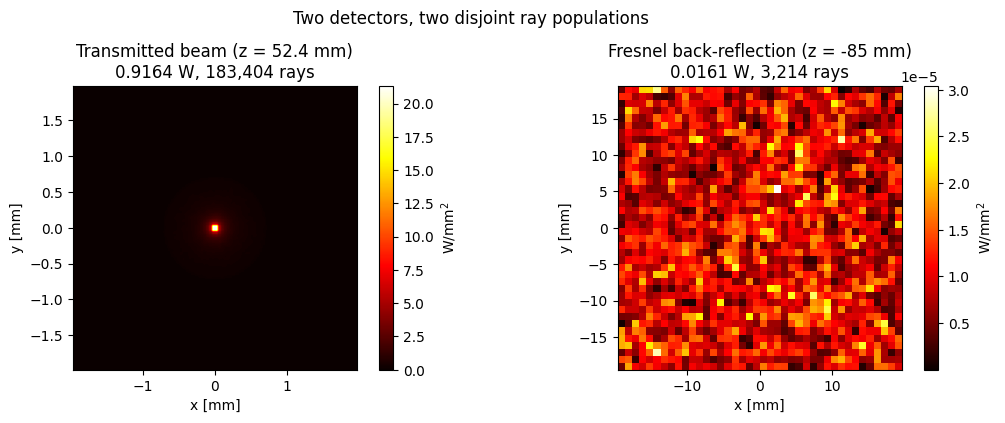

Forward : 0.9164 W
Backward: 0.0161 W
Escaped : 0.0669 W


In [7]:
# Forward and backward detectors catch disjoint populations: the transmitted
# beam, and the Fresnel reflection travelling back towards the source.
scene_fb = NSQScene()
scene_fb.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec_green, total_flux=1.0, aperture_radius=10.0),
)
scene_fb.add_lens('L', CoordinateSystem(z=0), DEMO_LENS)
scene_fb.add_detector(
    'D_fwd', CoordinateSystem(z=FOCUS_Z),
    IrradianceDetectorConfig(width=4, height=4, num_pixels_x=96, num_pixels_y=96),
)
# Coarse bins: the back-reflection carries ~2% of the flux, so fine pixels
# would show mostly shot noise.
scene_fb.add_detector(
    'D_back', CoordinateSystem(z=-85),
    IrradianceDetectorConfig(width=40, height=40, num_pixels_x=40, num_pixels_y=40),
)

result_fb = scene_fb.trace(num_rays=200_000, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, name, label in zip(axes, ['D_fwd', 'D_back'],
                           ['Transmitted beam (z = 52.4 mm)',
                            'Fresnel back-reflection (z = -85 mm)']):
    irr = result_fb.detectors[name]
    im = ax.imshow(irr.irradiance, origin='lower', cmap='hot', aspect='equal',
                   extent=[irr.x_coords[0], irr.x_coords[-1],
                           irr.y_coords[0], irr.y_coords[-1]])
    plt.colorbar(im, ax=ax, label='W/mm$^2$')
    ax.set_title(f'{label}\n{irr.total_flux:.4f} W, {irr.num_rays_hit:,} rays')
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.suptitle('Two detectors, two disjoint ray populations', fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig)

print(f"Forward : {result_fb.detectors['D_fwd'].total_flux:.4f} W")
print(f"Backward: {result_fb.detectors['D_back'].total_flux:.4f} W")
print(f"Escaped : {result_fb.total_flux_escaped:.4f} W")


### Profiling a beam at several planes

Because detectors absorb, a caustic scan is one trace per plane. The loop below
walks a single detector through focus:


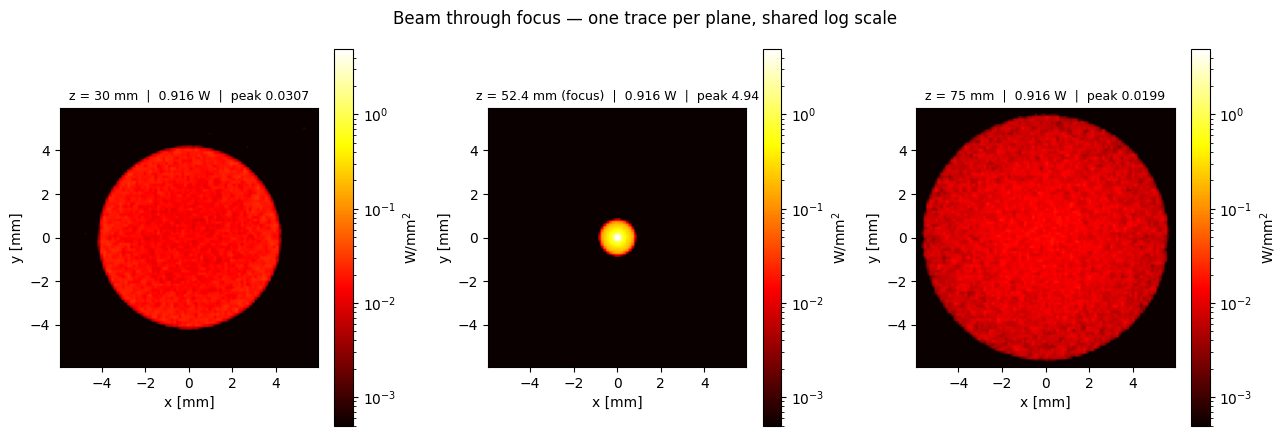

In [8]:
def beam_at(z, half_width=12.0, n_rays=60_000):
    """Trace the demo scene with a single detector at plane z."""
    s = NSQScene()
    s.add_source(
        'S', CoordinateSystem(z=-80),
        CollimatedSourceConfig(spectrum=spec_green, total_flux=1.0,
                               aperture_radius=10.0),
    )
    s.add_lens('L', CoordinateSystem(z=0), DEMO_LENS)
    s.add_detector(
        'D', CoordinateSystem(z=z),
        IrradianceDetectorConfig(width=half_width, height=half_width,
                                 num_pixels_x=96, num_pixels_y=96),
    )
    return s.trace(num_rays=n_rays, seed=42).detectors['D']


planes = [30.0, FOCUS_Z, 75.0]
maps = [beam_at(z) for z in planes]
vmax = max(m.irradiance.max() for m in maps)

# The focus is some 500x brighter than the planes either side of it, so a
# linear shared scale renders those two solid black. A shared log scale keeps
# the comparison honest and still shows the caustic.
from matplotlib.colors import LogNorm
norm = LogNorm(vmin=vmax * 1e-4, vmax=vmax)

# LogNorm masks the empty pixels rather than colouring them; paint them the
# floor colour so the unlit area reads as background instead of speckle.
cmap = plt.get_cmap('hot').copy()
cmap.set_bad(cmap(0.0))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, z, irr in zip(axes, planes, maps):
    im = ax.imshow(irr.irradiance, origin='lower', cmap=cmap, aspect='equal',
                   extent=[irr.x_coords[0], irr.x_coords[-1],
                           irr.y_coords[0], irr.y_coords[-1]],
                   norm=norm)
    plt.colorbar(im, ax=ax, label='W/mm$^2$')
    tag = ' (focus)' if abs(z - FOCUS_Z) < 1e-6 else ''
    ax.set_title(f'z = {z:g} mm{tag}  |  {irr.total_flux:.3f} W  |  '
                 f'peak {irr.irradiance.max():.3g}', fontsize=9)
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.suptitle('Beam through focus \u2014 one trace per plane, shared log scale',
             fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig)


## 6. Transmissive Detectors: `absorb=False`

Every detector config has an `absorb` field, default `True`: a ray that hits
the detector is recorded and then terminated, which is why section 5 called
detectors "absorbing" and needed one trace per plane to profile a beam.

Setting `absorb=False` makes the detector **transmissive**: the hit is still
recorded, but the ray continues on its original, unchanged direction instead
of stopping. That makes it possible to *tap* a beam mid-flight -- sample it
at an intermediate plane -- without disturbing what happens downstream, so a
single trace can record the same rays at two different planes at once. Below,
a non-absorbing detector sits partway through the converging beam and an
ordinary (absorbing) detector sits at focus; both see essentially the same
flux, because the tap did not remove any rays.

Tap (absorb=False) at z=35    : 0.9166 W, 183,435 rays
Focus (absorb=True) at z=52.4 : 0.9164 W, 183,404 rays
Nearly identical flux -- the tap sampled the beam without removing it.


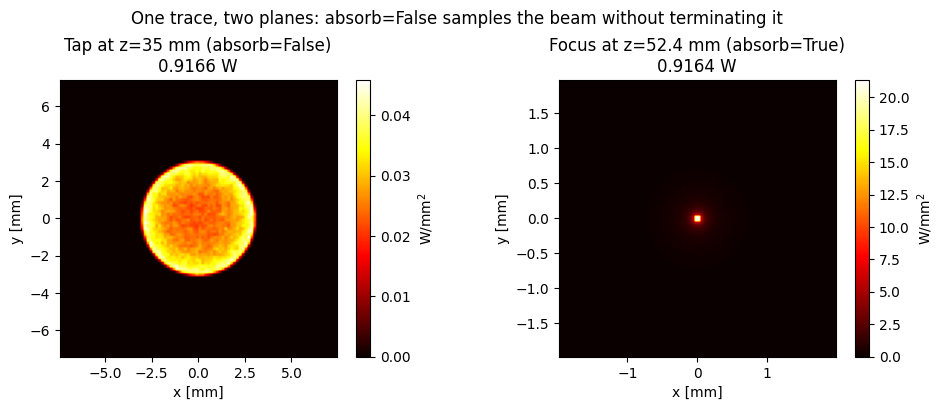

In [9]:
scene_tap = NSQScene()
scene_tap.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec_green, total_flux=1.0, aperture_radius=10.0),
)
scene_tap.add_lens('L', CoordinateSystem(z=0), DEMO_LENS)
# z = 35: partway between the lens and the focus at z = 52.4. The beam is
# already converging but still ~9 mm across, well inside the 15 mm detector.
scene_tap.add_detector(
    'D_tap', CoordinateSystem(z=35),
    IrradianceDetectorConfig(width=15, height=15, num_pixels_x=96, num_pixels_y=96,
                             absorb=False),
)
scene_tap.add_detector(
    'D_focus', CoordinateSystem(z=FOCUS_Z),
    IrradianceDetectorConfig(width=4, height=4, num_pixels_x=96, num_pixels_y=96),
)

result_tap = scene_tap.trace(num_rays=200_000, seed=42)
tap, focus = result_tap.detectors['D_tap'], result_tap.detectors['D_focus']

print(f"Tap (absorb=False) at z=35    : {tap.total_flux:.4f} W, {tap.num_rays_hit:,} rays")
print(f"Focus (absorb=True) at z=52.4 : {focus.total_flux:.4f} W, {focus.num_rays_hit:,} rays")
print("Nearly identical flux -- the tap sampled the beam without removing it.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, irr, title in zip(axes, [tap, focus],
                          ['Tap at z=35 mm (absorb=False)', 'Focus at z=52.4 mm (absorb=True)']):
    im = ax.imshow(irr.irradiance, origin='lower', cmap='hot', aspect='equal',
                   extent=[irr.x_coords[0], irr.x_coords[-1],
                           irr.y_coords[0], irr.y_coords[-1]])
    plt.colorbar(im, ax=ax, label='W/mm$^2$')
    ax.set_title(f'{title}\n{irr.total_flux:.4f} W')
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.suptitle('One trace, two planes: absorb=False samples the beam without terminating it', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Photometric Units

NSQ traces are **radiometric** throughout (watts, W/mm²); `optiland.nonsequential.units`
is a read-only conversion layer on top of a finished result, not part of the
trace loop. `to_photometric()` weights a detector's spectral content against
the CIE photopic luminous efficiency curve V(λ) to produce a photometric
quantity -- illuminance (lux) for a per-pixel map, or luminous flux (lumens)
for a scalar total.

`IrradianceMap` carries no wavelength breakdown of its own (only
`SpectralResult` does), so converting one requires an explicit
`wavelength_um` -- here the 0.55 µm the source used. Converting a spectrum
with negligible overlap with V(λ) (e.g. purely infrared) raises rather than
silently returning a near-zero photometric value.

Radiometric peak    : 31.167 W/mm²
Photometric peak    : 2.118e+10 lux
Total luminous flux : 622.8 lm  (from 0.9164 W radiometric at 0.55 µm)


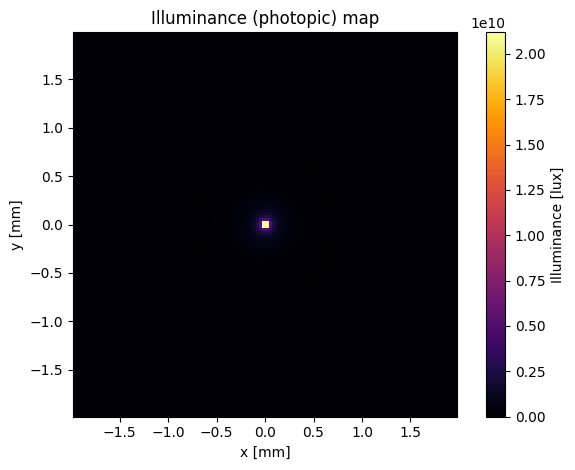

In [10]:
from optiland.nonsequential import to_photometric

# irr_map is the 0.55 um focused-spot IrradianceMap from section 1.
photo = to_photometric(irr_map, quantity='illuminance', wavelength_um=0.55)

print(f"Radiometric peak    : {irr_map.irradiance.max():.3f} W/mm²")
print(f"Photometric peak    : {photo.data.max():.3e} lux")
print(f"Total luminous flux : {photo.total:.1f} lm  "
      f"(from {irr_map.total_flux:.4f} W radiometric at 0.55 µm)")
# The peak looks absurd next to everyday illuminance values (full sun is
# ~100,000 lux) only because this 1 W beam is focused into a sub-millimetre
# spot -- W/mm^2 is already a huge areal density before the lm/W conversion
# is even applied. The total luminous flux (lm), a spot-size-independent
# quantity, is the number to compare against real sources: 623 lm is in the
# same ballpark as a bright handheld flashlight.

fig = photo.plot(cmap='inferno')
plt.tight_layout()
plt.show()

## Summary

- `IrradianceDetector` → `IrradianceMap`: 2D flux map, `irradiance` in W/mm²
- `FarFieldDetector` → `FarFieldPattern`: angular distribution, `intensity` in W/sr
- `SpectralDetector` → `SpectralResult`: per-wavelength 2D map; the binning range
  (`wl_min`/`wl_max`/`num_bins`) is in **µm**, like every other wavelength in Optiland
- `RayDatabaseDetector` → `RayDatabase`: full phase-space record; use `.to_dataframe()`
  for analysis
- `splat` controls how a ray's flux lands in the pixel grid: `bilinear` (default,
  differentiable), `hard` (nearest-pixel, what the fast NumPy path uses), or
  `gaussian` (a true differentiable Gaussian kernel, width `splat_sigma`)
- Detectors **absorb** by default: only the first detector along a ray's path
  records it, and one trace per plane is needed to profile a beam. Set
  `absorb=False` to record a hit without terminating the ray -- useful for
  tapping a beam mid-flight
- `optiland.nonsequential.units.to_photometric()` converts a finished radiometric
  result (W, W/mm²) to a photometric one (lm, lux) by weighting against CIE V(λ);
  it is a read-only conversion layer, not part of the trace loop
- Put the detector where the light actually goes. This lens has f = 49.1 mm and a
  47.4 mm back focal distance, so the focus is at z = 52.4 mm; a detector at z = 100
  would measure a 7.5 mm defocus blur, not a spot